In [1]:
#type: ignore
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import MultinomialNB, BernoulliNB, ComplementNB
from lightgbm import LGBMClassifier 
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

In [2]:
train_path = "./data/train.csv" 
test_path = "./data/test.csv" 

train_data = pd.read_csv(train_path) 
test_data = pd.read_csv(train_path) 

In [3]:
SEED = 42
reviews = train_data['review']
target = train_data['target'] 

reviews_test = test_data['review'] 
target_test = test_data['target']

In [4]:
review_train, review_val, target_train, target_val = train_test_split(reviews, target, test_size=0.2, stratify=target, random_state=SEED) 

In [5]:
bow_vectorizer = CountVectorizer() 
tfidf_vectorizer = TfidfVectorizer() 

review_train_bow = bow_vectorizer.fit_transform(review_train) 
review_val_bow = bow_vectorizer.transform(review_val) 

review_train_tfidf = tfidf_vectorizer.fit_transform(review_train) 
review_val_tfidf = tfidf_vectorizer.transform(review_val) 

In [6]:
models = [ 
    LogisticRegression(n_jobs=-1, class_weight="balanced", solver="lbfgs", max_iter=1000, random_state=SEED), 
    MultinomialNB(), 
    LGBMClassifier(n_estimators=100, learning_rate=0.1, objective="multiclass", num_class=3, class_weight="balanced", random_state=SEED, n_jobs=-1), 
    RandomForestClassifier(n_estimators=100, class_weight="balanced_subsample", random_state=SEED, n_jobs=-1),  
    LinearSVC(multi_class='ovr', class_weight='balanced', random_state=SEED), 
    DecisionTreeClassifier(), 
    BernoulliNB(), 
    SGDClassifier(n_jobs=-1, random_state=SEED, class_weight="balanced"), 
    ComplementNB(), 
    GradientBoostingClassifier(n_estimators=100, random_state=SEED)
]

In [12]:
import time
from sklearn.metrics import f1_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

data_types = {
    "BoW": review_train_bow, 
    "TF-IDF": review_train_tfidf 
}

results = []

for data_name, x in data_types.items():

    y = target_train 

    for model in models: 
        model_name = model.__class__.__name__

        print(f"\nRunning {model_name} with {data_name}...")

        if isinstance(model, LGBMClassifier): 
            x = x.astype('float32')
        
        scores = cross_val_score(
            model, 
            x, 
            y, 
            cv=skf, 
            scoring="f1_macro", 
            n_jobs=-1 
        )

        results.append({
            "Model": model_name, 
            "Data Type": data_name, 
            "F1 (Macro)": round(scores.mean(), 4), 
            "F1 std": round(scores.std(), 4)  
        })


results_df = pd.DataFrame(results)
results_df = results_df.sort_values("F1 (Macro)", ascending=False).reset_index(drop=True)
results_df.to_csv("./models_comparation.csv", index=False, encoding="utf-8") 
print(results_df)


Running LogisticRegression with BoW...

Running MultinomialNB with BoW...

Running LGBMClassifier with BoW...

Running RandomForestClassifier with BoW...

Running LinearSVC with BoW...

Running DecisionTreeClassifier with BoW...

Running BernoulliNB with BoW...

Running SGDClassifier with BoW...

Running ComplementNB with BoW...

Running GradientBoostingClassifier with BoW...

Running LogisticRegression with TF-IDF...

Running MultinomialNB with TF-IDF...

Running LGBMClassifier with TF-IDF...

Running RandomForestClassifier with TF-IDF...

Running LinearSVC with TF-IDF...

Running DecisionTreeClassifier with TF-IDF...

Running BernoulliNB with TF-IDF...

Running SGDClassifier with TF-IDF...

Running ComplementNB with TF-IDF...

Running GradientBoostingClassifier with TF-IDF...
                         Model Data Type  F1 (Macro)  F1 std
0                SGDClassifier    TF-IDF      0.6033  0.0060
1                SGDClassifier       BoW      0.5997  0.0068
2           LogisticRegress

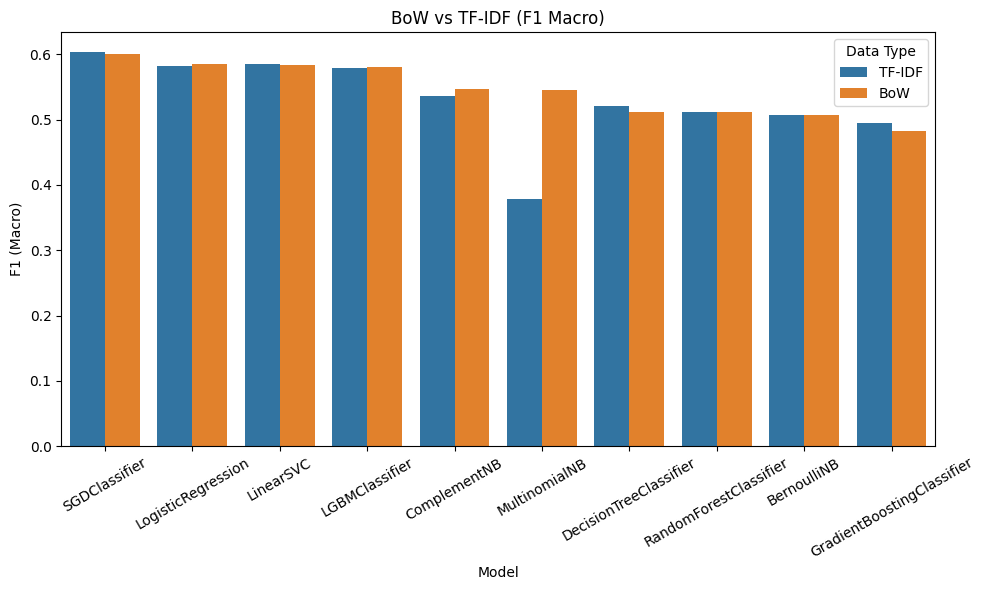

In [13]:
results_df = pd.read_csv("./models_comparation.csv")

plt.figure(figsize=(10,6))
sns.barplot(
    data=results_df,
    x="Model",
    y="F1 (Macro)",
    hue="Data Type"
)

plt.title("BoW vs TF-IDF (F1 Macro)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

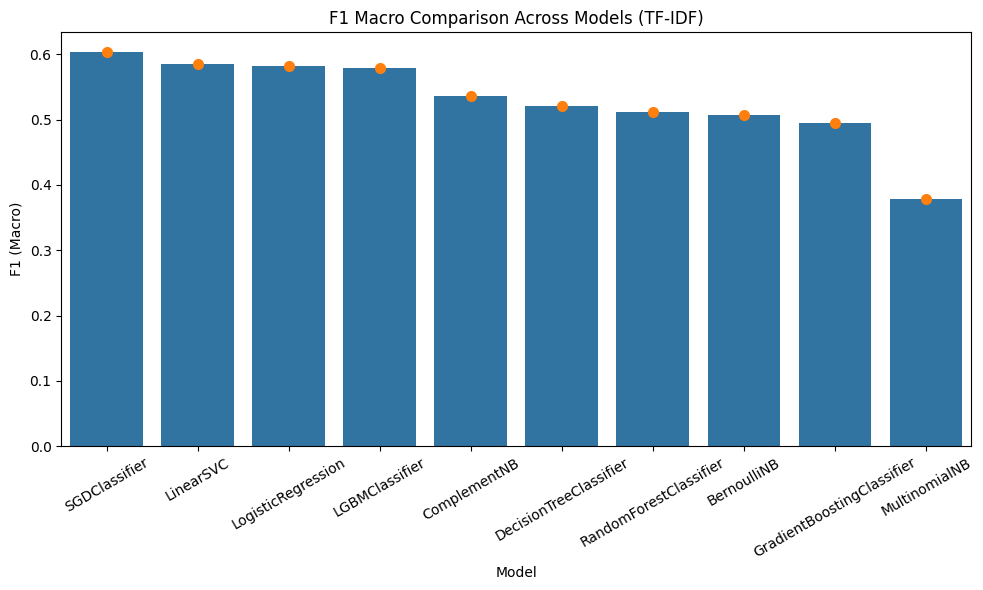

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# lọc TF-IDF
df_tfidf = results_df[results_df["Data Type"] == "TF-IDF"]

plt.figure(figsize=(10,6))

sns.barplot(
    data=df_tfidf,
    x="Model",
    y="F1 (Macro)"
)

sns.stripplot(
    data=df_tfidf,
    x="Model",
    y="F1 (Macro)",
    size=8
)

plt.xticks(rotation=30)
plt.title("F1 Macro Comparison Across Models (TF-IDF)")
plt.tight_layout()
plt.show()

In [7]:
pipe = Pipeline([
    ("tfidf", TfidfVectorizer()), 
    ("sgdc", SGDClassifier(n_jobs=-1, random_state=SEED, class_weight="balanced"))
])


pipe.fit(review_train, target_train) 

y_pred = pipe.predict(review_val) 

report = classification_report(target_val, y_pred)

print(report)

              precision    recall  f1-score   support

           0       0.58      0.74      0.65      1146
           1       0.27      0.25      0.26       612
           2       0.95      0.92      0.93      7938

    accuracy                           0.85      9696
   macro avg       0.60      0.63      0.61      9696
weighted avg       0.86      0.85      0.86      9696



* SGDClassifier
* LogisticRegression
* LinearSVC

Tune parameters

In [34]:
def plot_param_search(pipe, X, y, param_name, param_values,
                      param_label=None, scoring="f1_macro",
                      n_splits=5, ax=None, title=None):

    means, stds = [], []
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    for val in param_values:
        pipe.set_params(**{param_name: val})
        scores = cross_val_score(pipe, X, y, cv=cv, scoring=scoring, n_jobs=-1)
        means.append(scores.mean())
        stds.append(scores.std())

    means    = np.array(means)
    stds     = np.array(stds)
    labels   = param_label if param_label else [str(v) for v in param_values]
    best_idx = np.argmax(means)

    if ax is None:
        _, ax = plt.subplots(figsize=(6, 4))

    x = np.arange(len(labels))
    ax.fill_between(x, means - stds, means + stds, alpha=0.15, color="#4C72B0")
    ax.plot(x, means, "o-", linewidth=2.2, color="#4C72B0", markersize=7)
    ax.axvline(best_idx, linestyle="--", linewidth=1.8,
               color="#e74c3c", label=f"best: {labels[best_idx]}")
    ax.annotate(f"{means[best_idx]:.4f}",
                xy=(best_idx, means[best_idx]),
                xytext=(8, 6), textcoords="offset points",
                fontsize=9, color="#e74c3c", fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=20, ha="right", fontsize=9)
    ax.set_ylabel(scoring, fontsize=9)
    ax.set_title(title or param_name, fontsize=10, fontweight="bold")
    ax.legend(fontsize=8, loc="lower right")
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    ax.spines[["top", "right"]].set_visible(False)

    print(f"  [{param_name}]  best={labels[best_idx]}"
          f"  mean={means[best_idx]:.4f}  std={stds[best_idx]:.4f}")

    return labels[best_idx], means[best_idx]

In [35]:
def run_param_search(model, model_name, param_grid, X, y):

    pipe = Pipeline([
        ("tfidf", TfidfVectorizer()),
        ("clf",   model)
    ])

    n_plots = len(param_grid)
    cols    = 2
    rows    = (n_plots + 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(13, 4 * rows),
                             facecolor="#f8f9fa")
    axes = axes.flatten()

    fig.suptitle(f"{model_name}  —  param search  ({"f1_macro"}, CV={5})",
                 fontsize=13, fontweight="bold", y=1.01)

    best_summary = {}

    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")

    for i, (param, config) in enumerate(param_grid.items()):
        axes[i].set_facecolor("white")
        param_name = param if "tfidf" in param else f"clf__{param}"

        best_label, best_score = plot_param_search(
            pipe, X, y,
            param_name   = param_name,
            param_values = config["values"],
            param_label  = config.get("labels"),
            ax           = axes[i],
            title        = param
        )
        best_summary[param] = {"best": best_label, "score": best_score}

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout(pad=2.0)
    fname = f"{model_name.replace(' ', '_')}_param_search.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()

    return best_summary

    

TF-IDF for 3 models

In [30]:
TFIDF_GRID = {
    "tfidf__ngram_range": {
        "values": [(1,1), (1,2), (1,3), (2,2)], 
        "labels": ["(1,1)", "(1,2)", "(1,3)", "(2,2)"]
    }, 
    "tfidf__max_features": {
        "values": [5000, 10000, 20000, 30000, 40000], 
        "labels": ["5k", "10k", "20k", "30k", "40k"]
    }, 
    "tfidf__sublinear_tf": {
        "values": [True, False], 
        "labels": ["True", "False"]
    }, 
    "tfidf__max_df": {
        "values": [0.8, 0.85, 0.9, 0.95, 1.0], 
        "labels": ["0.8", "0.85", "0.9", "0.95", "1.0"]
    }, 
    "tfidf__min_df": {
        "values": [1, 2, 5, 10],
        "labels": ["1","2","5","10"]
    },
    "tfidf__analyzer": {
        "values": ["word","char_wb"],
        "labels": ["word","char_wb"]
    }
}

In [46]:
LR_GRID = {**TFIDF_GRID,
    "C" : {
        "values": [0.001,0.01,0.1,1,10,100],
        "labels": ["0.001","0.01","0.1","1","10","100"]
    },
    "solver" : {
        "values": ["lbfgs","saga"],
        "labels": ["lbfgs","saga"]
    }
}

SVC_GRID = {**TFIDF_GRID,
    "C" : {
        "values": [0.001,0.01,0.1,1,10,100],
        "labels": ["0.001","0.01","0.1","1","10","100"]
    },
    "loss" : {
        "values": ["hinge","squared_hinge"],
        "labels": ["hinge","squared_hinge"]
    }
}

SGD_GRID = {**TFIDF_GRID,
    "loss" : {
        "values": ["hinge","log_loss","modified_huber","squared_hinge"],
        "labels": ["hinge","log_loss","modified_huber","sq_hinge"]
    },
    "alpha" : {
        "values": [1e-5,1e-4,1e-3,1e-2,0.1],
        "labels": ["1e-5","1e-4","1e-3","1e-2","0.1"]
    },
    "penalty" : {
        "values": ["l1","l2"],
        "labels": ["l1","l2"]}
    ,
    "learning_rate": {
        "values": ["optimal","adaptive","invscaling"],
        "labels": ["optimal","adaptive","invscaling"]
    }
}

In [32]:
all_results = {}


  SGDClassifier
  [tfidf__ngram_range]  best=(1,2)  mean=0.6109  std=0.0070
  [tfidf__max_features]  best=5k  mean=0.5665  std=0.0063
  [tfidf__sublinear_tf]  best=True  mean=0.5628  std=0.0106
  [tfidf__max_df]  best=0.8  mean=0.5621  std=0.0103
  [tfidf__min_df]  best=5  mean=0.5664  std=0.0040
  [tfidf__analyzer]  best=char_wb  mean=0.5933  std=0.0056
  [clf__loss]  best=modified_huber  mean=0.5935  std=0.0033
  [clf__alpha]  best=1e-2  mean=0.5280  std=0.0101
  [clf__penalty]  best=l2  mean=0.3058  std=0.0026
  [clf__learning_rate]  best=invscaling  mean=0.3145  std=0.0028


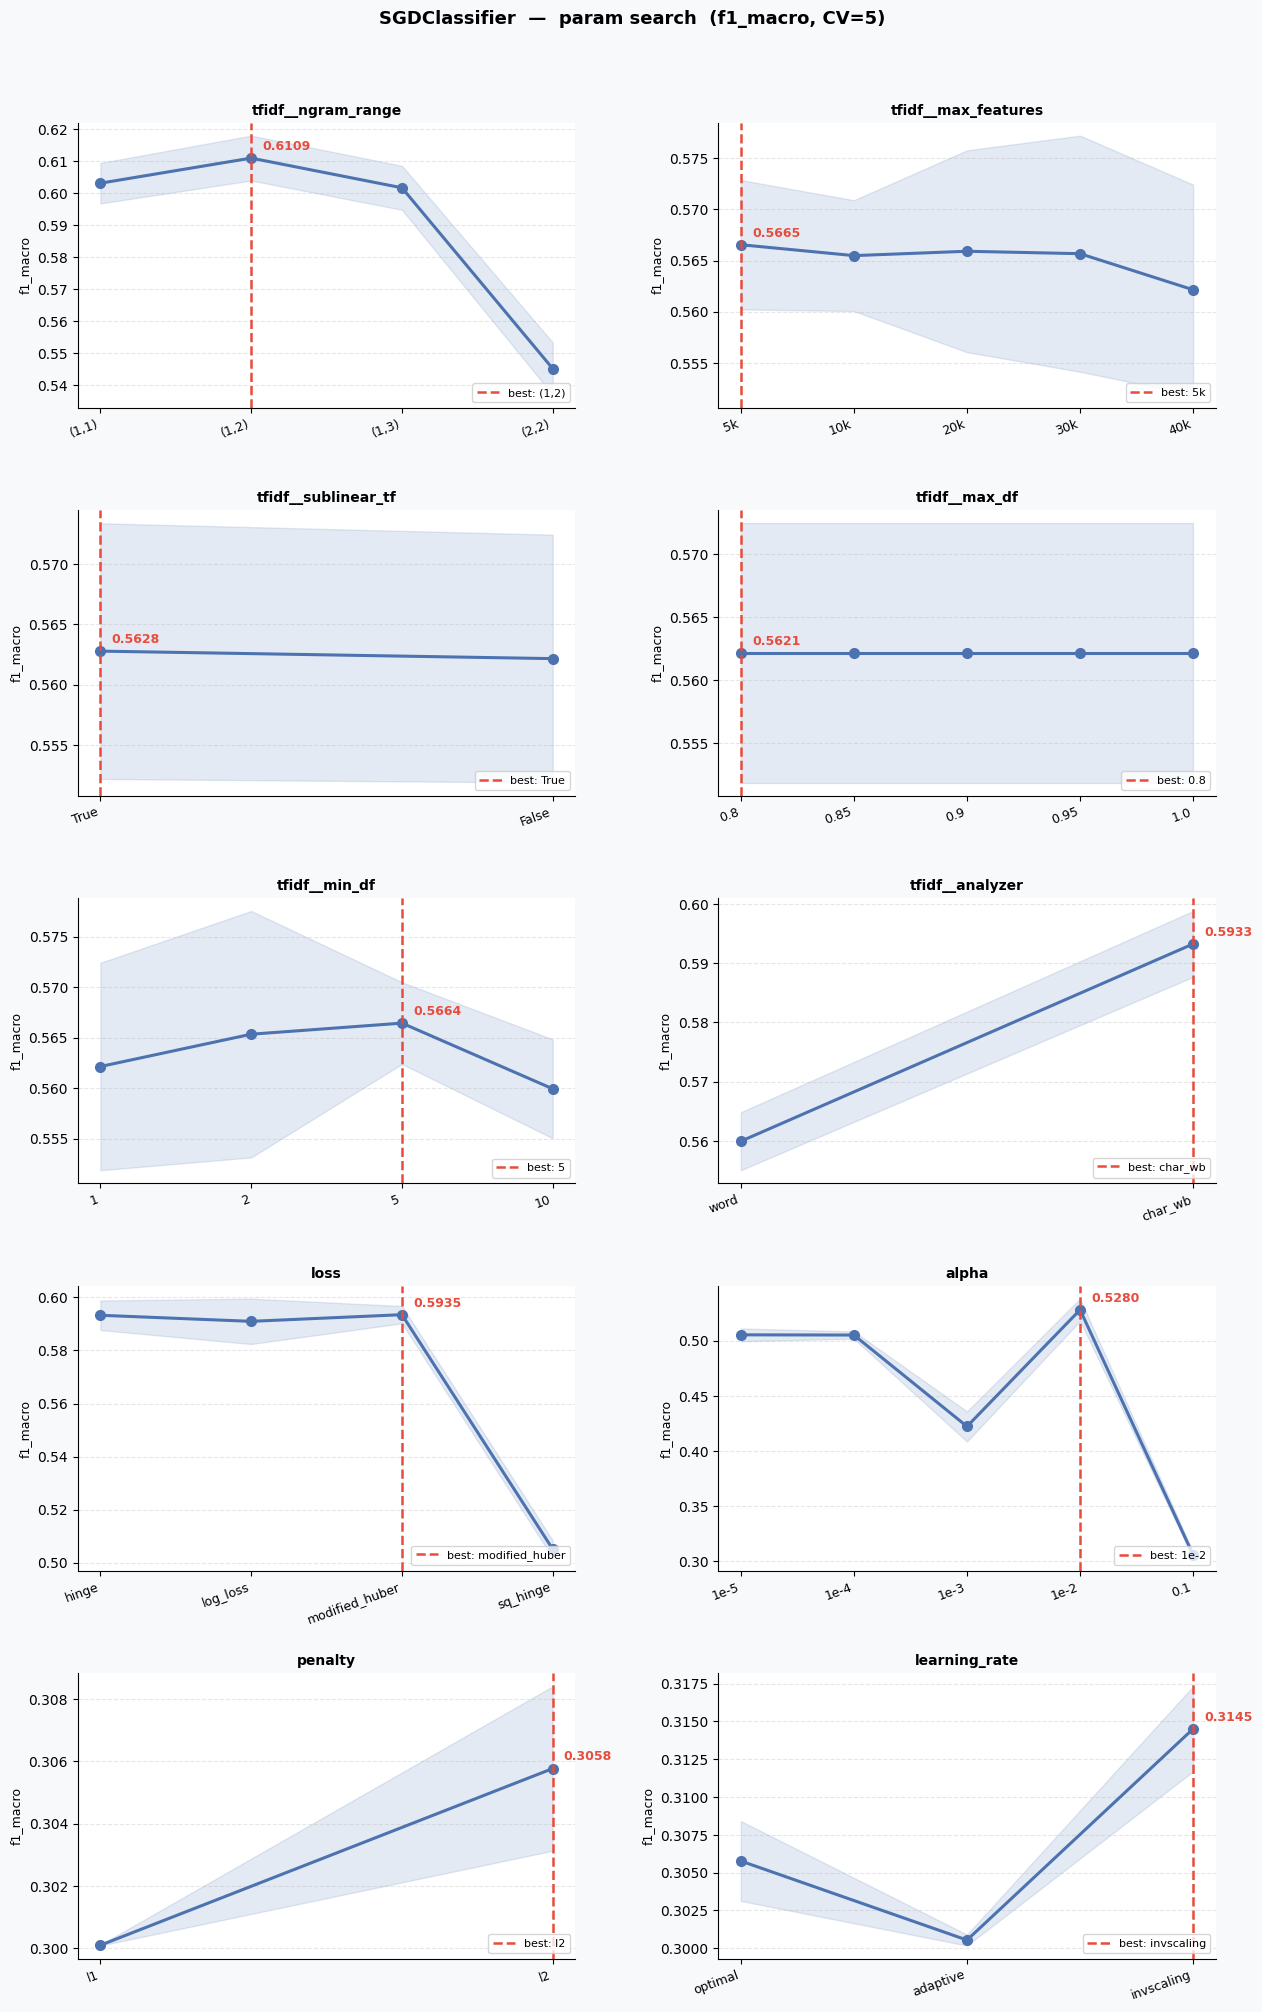

In [47]:
all_results["SGDClassifier"] = run_param_search(
    model=SGDClassifier(n_jobs=-1, random_state=SEED, class_weight="balanced"), 
    model_name="SGDClassifier", 
    param_grid=SGD_GRID, 
    X=review_train, y=target_train
)



  LinearSVC
  [tfidf__ngram_range]  best=(1,3)  mean=0.5987  std=0.0056
  [tfidf__max_features]  best=30k  mean=0.5699  std=0.0048
  [tfidf__sublinear_tf]  best=False  mean=0.5685  std=0.0061
  [tfidf__max_df]  best=0.8  mean=0.5685  std=0.0061
  [tfidf__min_df]  best=2  mean=0.5703  std=0.0056
  [tfidf__analyzer]  best=char_wb  mean=0.5903  std=0.0047
  [clf__C]  best=0.1  mean=0.5934  std=0.0078
  [clf__loss]  best=hinge  mean=0.5823  std=0.0013


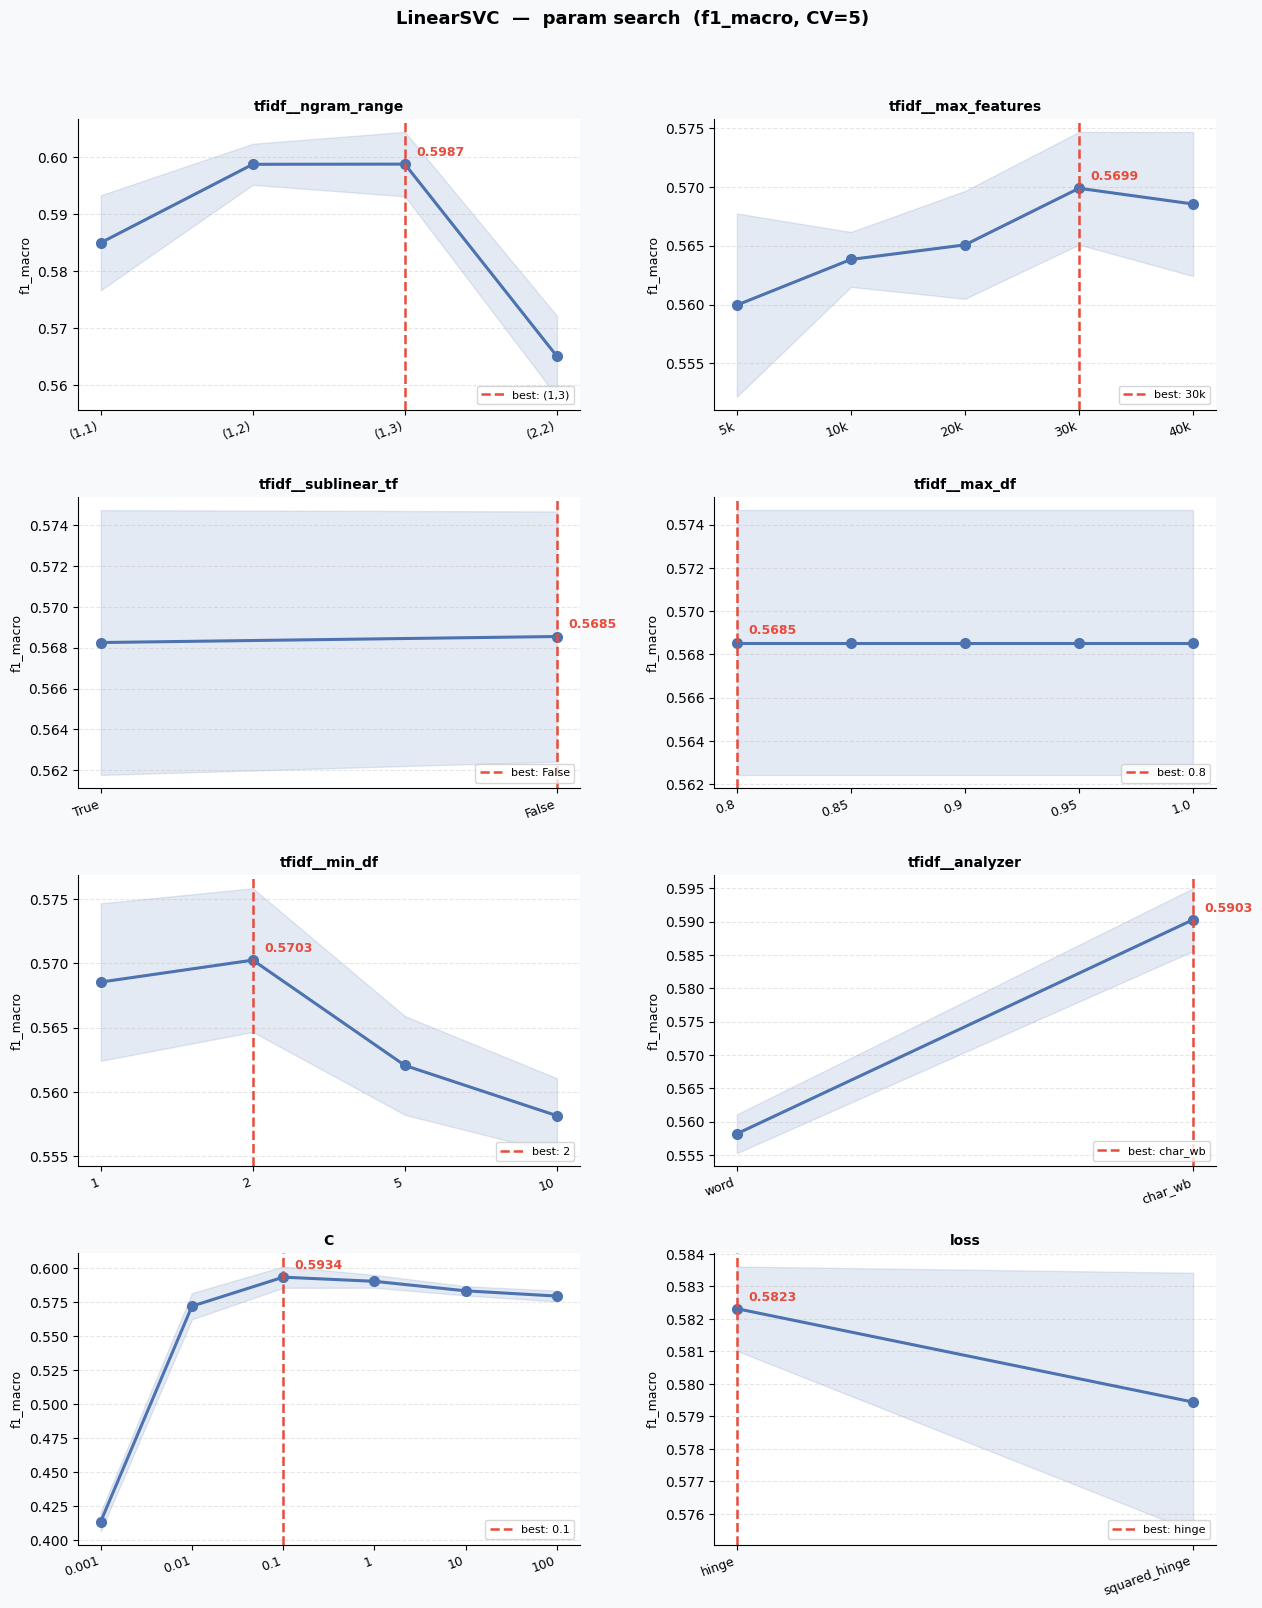

In [37]:
all_results["LinearSVC"] = run_param_search(
    model=LinearSVC(multi_class='ovr', class_weight='balanced', random_state=SEED),
    model_name = "LinearSVC",
    param_grid = SVC_GRID,
    X=review_train, y=target_train
)


  Logistic Regression
  [tfidf__ngram_range]  best=(1,2)  mean=0.6099  std=0.0047
  [tfidf__max_features]  best=40k  mean=0.5792  std=0.0031
  [tfidf__sublinear_tf]  best=True  mean=0.5795  std=0.0035
  [tfidf__max_df]  best=0.8  mean=0.5792  std=0.0031
  [tfidf__min_df]  best=2  mean=0.5796  std=0.0054
  [tfidf__analyzer]  best=char_wb  mean=0.5641  std=0.0058
  [clf__C]  best=0.1  mean=0.5651  std=0.0050
  [clf__solver]  best=lbfgs  mean=0.5477  std=0.0049


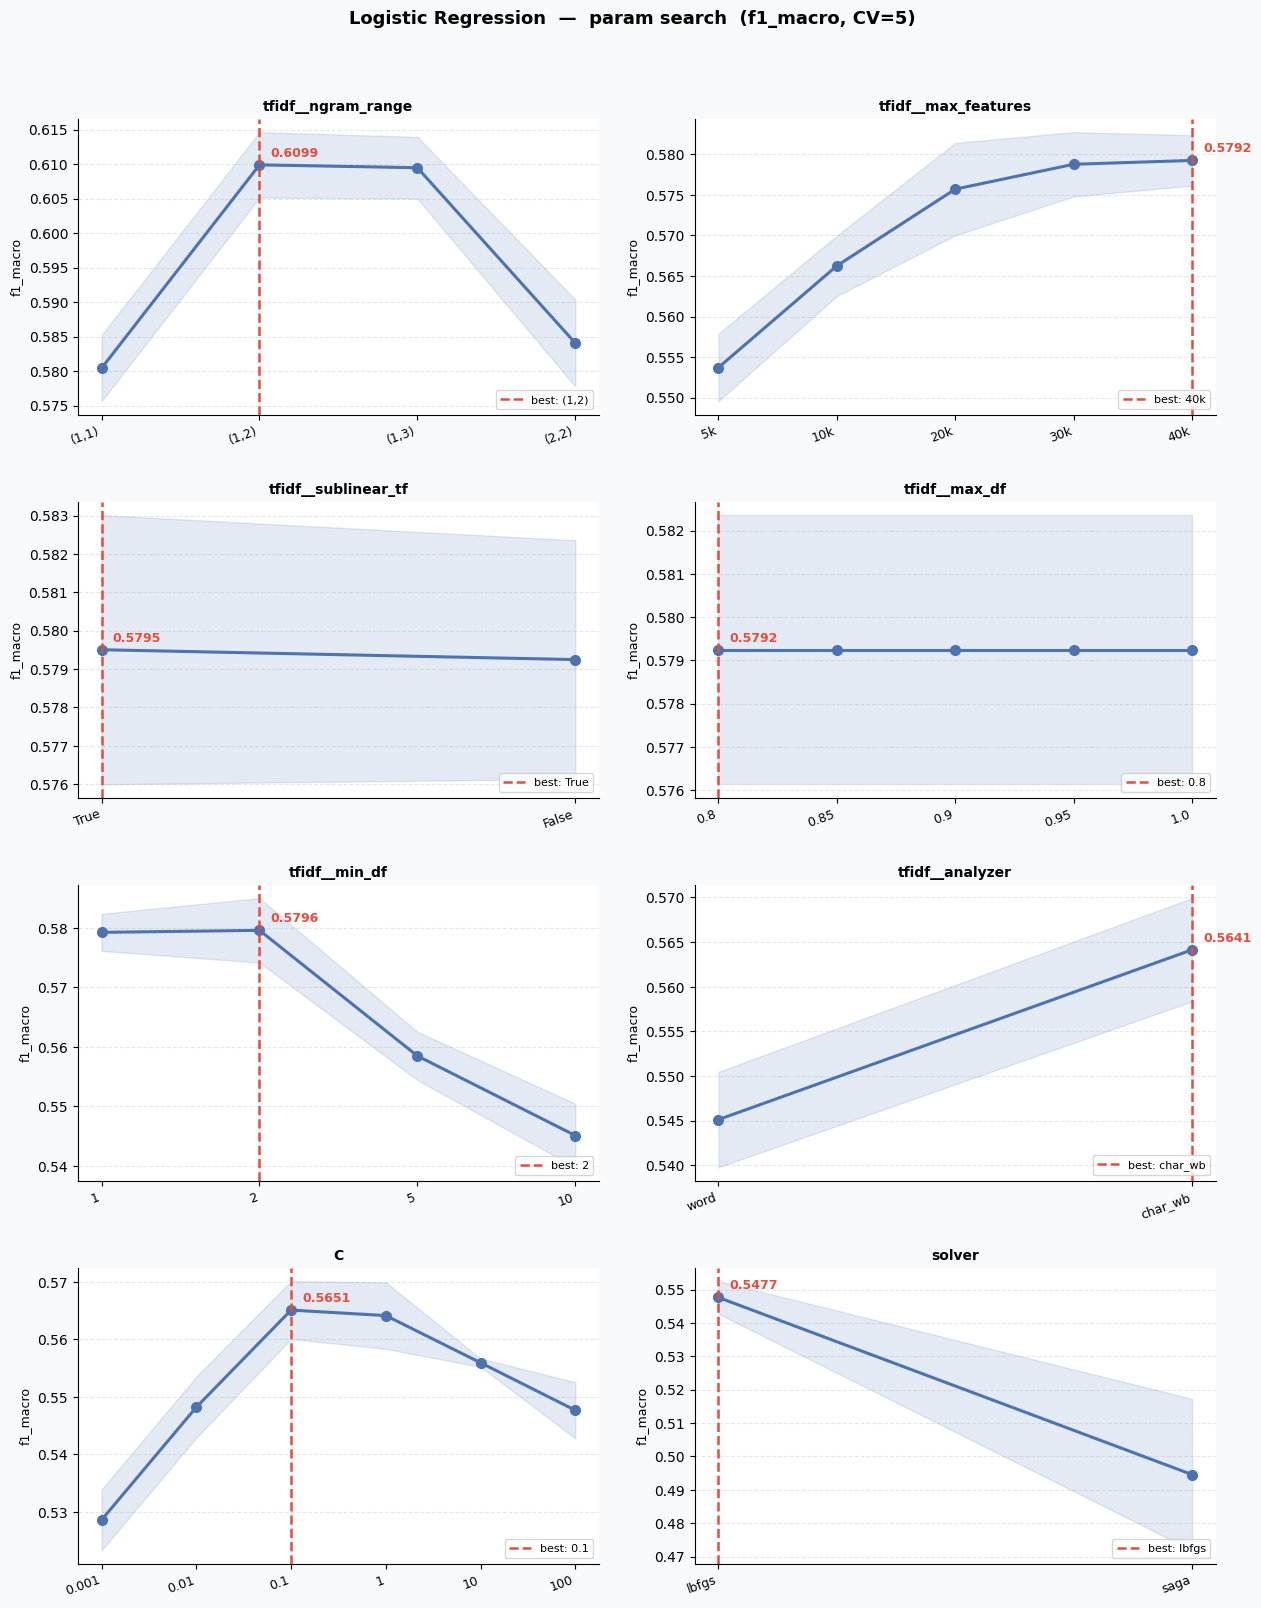

In [38]:
all_results["Logistic Regression"] = run_param_search(
    model      = LogisticRegression(n_jobs=-1, class_weight="balanced", max_iter=1000, random_state=SEED),
    model_name = "Logistic Regression",
    param_grid = LR_GRID,
    X=review_train, y=target_train
)

In [48]:
all_results

{'SGDClassifier': {'tfidf__ngram_range': {'best': '(1,2)',
   'score': np.float64(0.6109022725482667)},
  'tfidf__max_features': {'best': '5k',
   'score': np.float64(0.566546911885729)},
  'tfidf__sublinear_tf': {'best': 'True',
   'score': np.float64(0.5627665720046848)},
  'tfidf__max_df': {'best': '0.8', 'score': np.float64(0.5621460395139388)},
  'tfidf__min_df': {'best': '5', 'score': np.float64(0.5664434992522913)},
  'tfidf__analyzer': {'best': 'char_wb',
   'score': np.float64(0.5932732622179067)},
  'loss': {'best': 'modified_huber', 'score': np.float64(0.593498569592981)},
  'alpha': {'best': '1e-2', 'score': np.float64(0.5279895053051578)},
  'penalty': {'best': 'l2', 'score': np.float64(0.305767689841994)},
  'learning_rate': {'best': 'invscaling',
   'score': np.float64(0.3145069206402924)}},
 'LinearSVC': {'tfidf__ngram_range': {'best': '(1,3)',
   'score': np.float64(0.5987221556208394)},
  'tfidf__max_features': {'best': '30k',
   'score': np.float64(0.5698830818882864

In [40]:
def parse_best_value(param, label):
    if "ngram_range" in param:
        return tuple(int(x) for x in label.strip("()").split(","))
    if "max_features" in param:
        if label == "None": return None
        return int(label.replace("k","")) * 1000
    if label == "True":  return True
    if label == "False": return False
    if label == "None":  return None
    try:    return int(label)
    except: pass
    try:    return float(label)
    except: pass
    return label

In [41]:
def build_subset_grid(best_params):
    subset = {}
    for key, best_val in best_params.items():
        if   key == "tfidf__ngram_range":
            neighbors = {(1,1):[(1,1),(1,2)], (1,2):[(1,1),(1,2),(1,3)],
                         (1,3):[(1,2),(1,3)], (2,2):[(1,2),(2,2)]}
            subset[key] = neighbors.get(best_val, [best_val])

        elif key == "tfidf__max_features":
            neighbors = {None:[50000,None], 50000:[30000,50000,None],
                         30000:[10000,30000,50000], 10000:[5000,10000,30000],
                         5000:[5000,10000]}
            subset[key] = neighbors.get(best_val, [best_val])

        elif key == "tfidf__sublinear_tf":
            subset[key] = [True, False]

        elif key == "tfidf__min_df":
            neighbors = {1:[1,2], 2:[1,2,5], 5:[2,5,10], 10:[5,10]}
            subset[key] = neighbors.get(best_val, [best_val])

        elif key == "tfidf__max_df":
            neighbors = {0.80:[0.80,0.85], 0.85:[0.80,0.85,0.90],
                         0.90:[0.85,0.90,0.95], 0.95:[0.90,0.95,1.0],
                         1.0:[0.95,1.0]}
            subset[key] = neighbors.get(best_val, [best_val])

        elif key == "clf__C":
            neighbors = {0.001:[0.001,0.01], 0.01:[0.001,0.01,0.1],
                         0.1:[0.01,0.1,1.0], 1:[0.1,1.0,10],
                         10:[1.0,10,100],   100:[10,100]}
            subset[key] = neighbors.get(best_val, [best_val])

        elif key == "clf__alpha":
            neighbors = {1e-5:[1e-5,1e-4], 1e-4:[1e-5,1e-4,1e-3],
                         1e-3:[1e-4,1e-3,1e-2], 1e-2:[1e-3,1e-2,0.1],
                         0.1:[1e-2,0.1]}
            subset[key] = neighbors.get(best_val, [best_val])

        else:
            subset[key] = [best_val]   # giữ nguyên best

    return subset

In [42]:
def extract_best_params(all_results):
    extracted = {}
    for model_name, summary in all_results.items():
        extracted[model_name] = {}
        for param, info in summary.items():
            full_key = param if "tfidf" in param else f"clf__{param}"
            extracted[model_name][full_key] = parse_best_value(param, info["best"])
    return extracted

In [49]:
best_params_per_model = extract_best_params(all_results)

In [68]:
# Chuyển best_params_per_model thành DataFrame
df_best_params = pd.DataFrame.from_dict(best_params_per_model, orient='index').T
df_best_params.index.name = 'Parameter'

# Hiển thị dataframe
print("Best Parameters Per Model:")
print(df_best_params)

# Lưu ra CSV
df_best_params.to_csv("best_params_per_model.csv", encoding="utf-8")
print("\n✓ Đã lưu best_params_per_model.csv")

Best Parameters Per Model:
                      SGDClassifier LinearSVC Logistic Regression
Parameter                                                        
tfidf__ngram_range           (1, 2)    (1, 3)              (1, 2)
tfidf__max_features            5000     30000               40000
tfidf__sublinear_tf            True     False                True
tfidf__max_df                   0.8       0.8                 0.8
tfidf__min_df                     5         2                   2
tfidf__analyzer             char_wb   char_wb             char_wb
clf__loss            modified_huber     hinge                 NaN
clf__alpha                     0.01       NaN                 NaN
clf__penalty                     l2       NaN                 NaN
clf__learning_rate       invscaling       NaN                 NaN
clf__C                          NaN       0.1                 0.1
clf__solver                     NaN       NaN               lbfgs

✓ Đã lưu best_params_per_model.csv


In [69]:
df_best_params

,SGDClassifier,LinearSVC,Logistic Regression
Parameter,,,
tfidf__ngram_range,"(1, 2)","(1, 3)","(1, 2)"
tfidf__max_features,5000,30000,40000
tfidf__sublinear_tf,True,False,True
tfidf__max_df,0.8,0.8,0.8
tfidf__min_df,5,2,2
tfidf__analyzer,char_wb,char_wb,char_wb
clf__loss,modified_huber,hinge,NaN
clf__alpha,0.01,NaN,NaN
clf__penalty,l2,NaN,NaN


In [61]:
subset_grid = build_subset_grid(best_params_per_model["LinearSVC"])
print(subset_grid)

{'tfidf__ngram_range': [(1, 2), (1, 3)], 'tfidf__max_features': [10000, 30000, 50000], 'tfidf__sublinear_tf': [True, False], 'tfidf__max_df': [0.8, 0.85], 'tfidf__min_df': [1, 2, 5], 'tfidf__analyzer': ['char_wb'], 'clf__C': [0.01, 0.1, 1.0], 'clf__loss': ['hinge']}


In [50]:
LABELS = ["Negative", "Neutral", "Positive"]
MODEL_CONFIGS = {
    "Logistic Regression": LogisticRegression(n_jobs=-1, class_weight="balanced", max_iter=1000, random_state=SEED), 
    "LinearSVC" : LinearSVC(multi_class='ovr', class_weight='balanced', random_state=SEED), 
    "SGDClassifier": SGDClassifier(n_jobs=-1, random_state=SEED, class_weight="balanced")
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) 

final_results = {}

for model_name, model in MODEL_CONFIGS.items(): 
    print(f"\n{'='*55}")
    print(f"  GridSearchCV: {model_name}")
    print(f"{'='*55}")

    subset_grid = build_subset_grid(best_params_per_model[model_name])

    pipe = Pipeline(
        [
            ("tfidf", TfidfVectorizer()), 
            ("clf", model) 
        ]
    )

    gs = GridSearchCV(
        pipe, 
        subset_grid, 
        cv=cv, 
        scoring="f1_macro", 
        n_jobs=-1, 
        return_train_score=True, 
        verbose=1, 
        refit=True
    )

    gs.fit(review_train, target_train)

    target_predict = gs.predict(review_val) 

    final_results[model_name] = {
        "best_estimator": gs.best_estimator_, 
        "best_params": gs.best_params_, 
        "best_cv_score": gs.best_score_, 
        "test_report": classification_report(target_val, target_predict, target_names=LABELS, output_dict=True),
        "target_predict": target_predict 
    }

    


  GridSearchCV: Logistic Regression
Fitting 5 folds for each of 108 candidates, totalling 540 fits


c:\Users\NinhDB\tiki-sentiment-analytics\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



  GridSearchCV: LinearSVC
Fitting 5 folds for each of 216 candidates, totalling 1080 fits


c:\Users\NinhDB\tiki-sentiment-analytics\.venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(



  GridSearchCV: SGDClassifier
Fitting 5 folds for each of 216 candidates, totalling 1080 fits


In [51]:
final_results

{'Logistic Regression': {'best_estimator': Pipeline(steps=[('tfidf',
                   TfidfVectorizer(analyzer='char_wb', max_df=0.8,
                                   max_features=40000, ngram_range=(1, 3),
                                   sublinear_tf=True)),
                  ('clf',
                   LogisticRegression(class_weight='balanced', max_iter=1000,
                                      n_jobs=-1, random_state=42))]),
  'best_params': {'clf__C': 1.0,
   'clf__solver': 'lbfgs',
   'tfidf__analyzer': 'char_wb',
   'tfidf__max_df': 0.8,
   'tfidf__max_features': 40000,
   'tfidf__min_df': 1,
   'tfidf__ngram_range': (1, 3),
   'tfidf__sublinear_tf': True},
  'best_cv_score': np.float64(0.578889228660144),
  'test_report': {'Negative': {'precision': 0.54421768707483,
    'recall': 0.6980802792321117,
    'f1-score': 0.6116207951070336,
    'support': 1146.0},
   'Neutral': {'precision': 0.1801916932907348,
    'recall': 0.46078431372549017,
    'f1-score': 0.259072117593

In [53]:
import json
import joblib

# Lưu toàn bộ final_results (bao gồm best_estimator) dưới dạng pickle
joblib.dump(final_results, "final_results.pkl")
print("✓ Đã lưu final_results.pkl")

✓ Đã lưu final_results.pkl


In [54]:
rows = []

for name, result in final_results.items(): 
    r = result["test_report"] 

    rows.append(
        {
            'Model': name, 
            "CV F1": round(result['best_cv_score'], 4), 
            "Test F1": round(r["macro avg"]["f1-score"], 4),
            "Precision": round(r["macro avg"]["precision"], 4), 
            "Recall": round(r["macro avg"]["recall"], 4), 
            "Accuracy": round(r["accuracy"], 4) 
        }
    )
df_final = (pd.DataFrame(rows).sort_values("Test F1", ascending=False).reset_index(drop=True))

print(df_final.to_string(index=False))

              Model  CV F1  Test F1  Precision  Recall  Accuracy
          LinearSVC 0.6076   0.6125     0.5943  0.6364    0.8458
Logistic Regression 0.5789   0.5849     0.5643  0.6572    0.7770
      SGDClassifier 0.4162   0.4337     0.5640  0.4268    0.8305


In [84]:
df_final

,Model,CV F1,Test F1,Precision,Recall,Accuracy
0,LinearSVC,0.6076,0.6125,0.5943,0.6364,0.8458
1,Logistic Regression,0.5789,0.5849,0.5643,0.6572,0.7770
2,SGDClassifier,0.4162,0.4337,0.5640,0.4268,0.8305


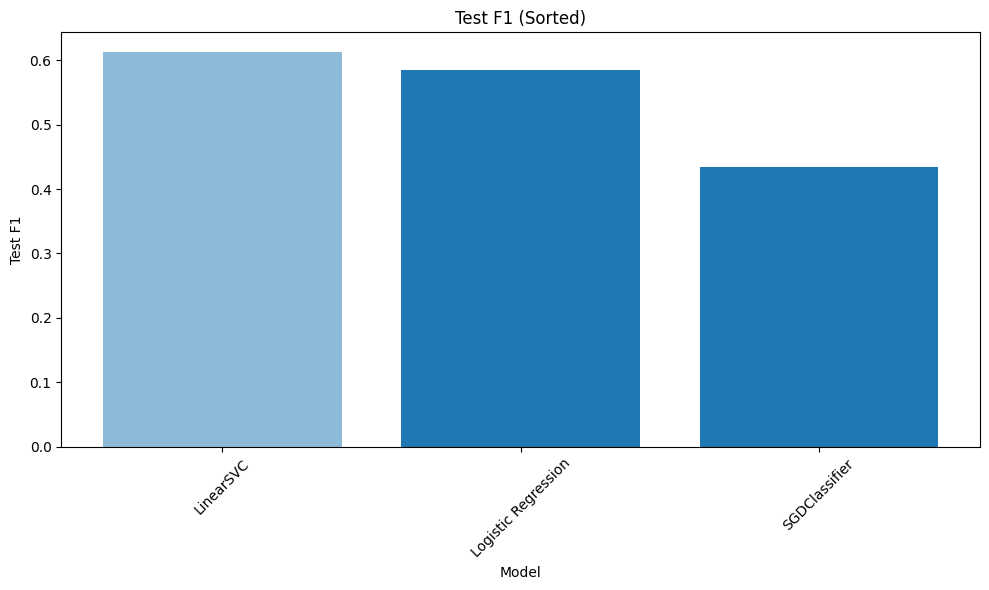

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

bars = plt.bar(df_final['Model'], df_final['Test F1'])

# Highlight model tốt nhất
bars[0].set_alpha(0.5)  # model top vì bạn đã sort giảm dần

plt.xlabel('Model')
plt.ylabel('Test F1')
plt.title('Test F1 (Sorted)')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [63]:
best_name = df_final.iloc[0]["Model"]
best_pipe = final_results[best_name]["best_estimator"]

target_pred = best_pipe.predict(reviews_test) 

report = classification_report(target_test, target_pred) 

print(report)


              precision    recall  f1-score   support

           0       0.66      0.81      0.73      5728
           1       0.41      0.47      0.44      3062
           2       0.96      0.92      0.94     39686

    accuracy                           0.88     48476
   macro avg       0.68      0.73      0.70     48476
weighted avg       0.89      0.88      0.88     48476



In [88]:
best_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


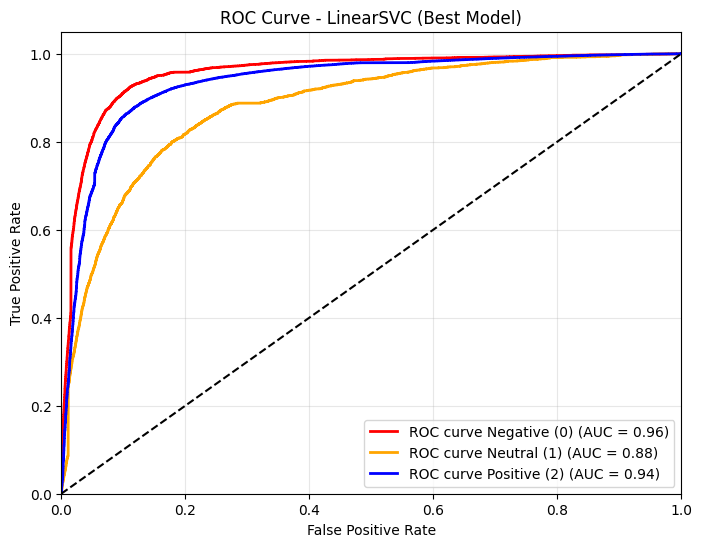

In [86]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

# 1. Chuẩn bị dữ liệu: Chuyển nhãn về dạng nhị phân (One-vs-Rest)
y_test_bin = label_binarize(target_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

# 2. Lấy điểm số dự đoán (Scores) từ best_pipe
# Nếu là LinearSVC dùng decision_function, nếu là LogisticRegression dùng predict_proba
if hasattr(best_pipe, "predict_proba"):
    y_score = best_pipe.predict_proba(reviews_test)
else:
    y_score = best_pipe.decision_function(reviews_test)

# 3. Vẽ biểu đồ
plt.figure(figsize=(8, 6))
colors = ['red', 'orange', 'blue']
labels = ['Negative (0)', 'Neutral (1)', 'Positive (2)']

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2, 
             label=f'ROC curve {labels[i]} (AUC = {roc_auc:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve - {best_name} (Best Model)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

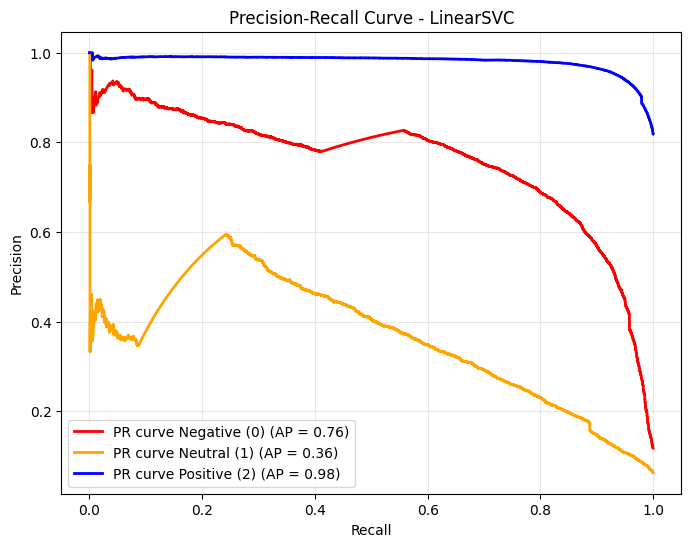

In [87]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(8, 6))

for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])
    average_precision = average_precision_score(y_test_bin[:, i], y_score[:, i])
    plt.plot(recall, precision, color=colors[i], lw=2,
             label=f'PR curve {labels[i]} (AP = {average_precision:0.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve - {best_name}')
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.show()

In [64]:
def plot_confusion_matrix(y_true, y_pred, figure_name='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred)
    cm_percent = cm.astype('float')/cm.sum(axis=1)[:, np.newaxis] * 100 
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_percent)
    disp.plot(cmap=plt.cm.Blues, values_format='.2f')
    plt.title(figure_name)
    plt.show()

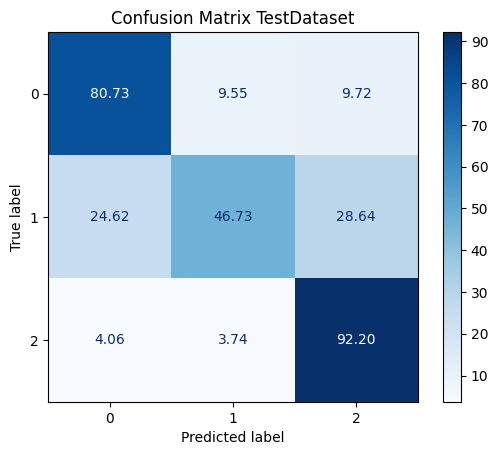

In [65]:
plot_confusion_matrix(target_test, target_pred, figure_name='Confusion Matrix TestDataset')

c:\Users\NinhDB\tiki-sentiment-analytics\.venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\NinhDB\tiki-sentiment-analytics\.venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\NinhDB\tiki-sentiment-analytics\.venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\NinhDB\tiki-sentiment-analytics\.venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\NinhDB\tiki-sentiment-analytics\.venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


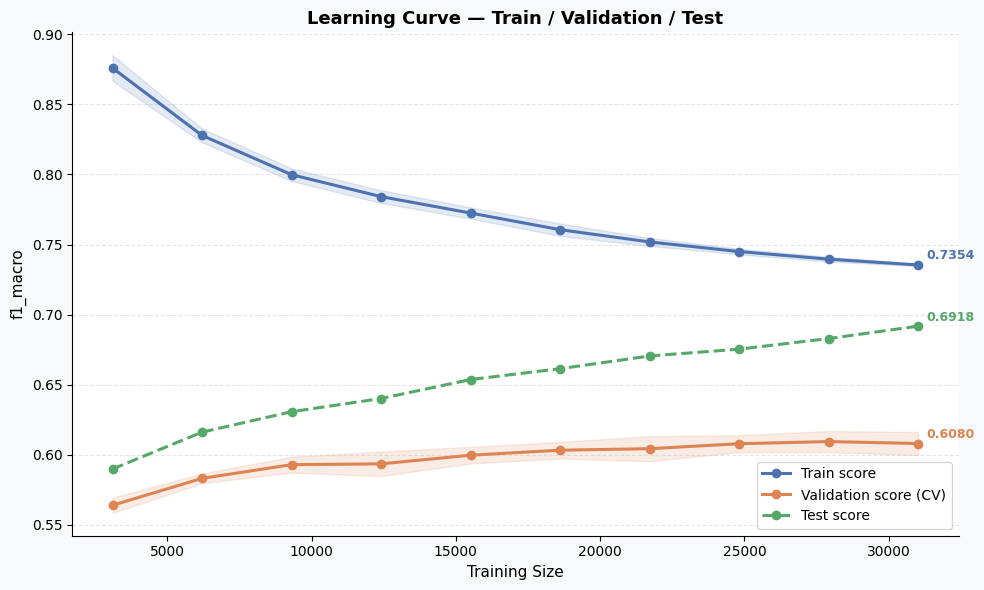

In [66]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

def plot_learning_curve(best_pipe, X_train, y_train, X_test, y_test,
                        scoring="f1_macro", cv=5, n_points=10):
    
    train_sizes = np.linspace(0.1, 1.0, n_points)

    train_sizes_abs, train_scores, val_scores = learning_curve(
        best_pipe,                       
        X_train, y_train,
        train_sizes = train_sizes,
        cv          = cv,
        scoring     = scoring,
        n_jobs      = -1,
        shuffle     = True,
        random_state= 42
    )

    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    
    from sklearn.base import clone

    test_scores = []
    for size in train_sizes_abs:
        pipe_clone = clone(best_pipe)                       # copy nguyên params
        pipe_clone.fit(X_train[:size], y_train[:size])      # fit trên subset
        score = pipe_clone.score_func if hasattr(pipe_clone, "score_func") else None

        from sklearn.metrics import f1_score
        y_pred = pipe_clone.predict(X_test)
        test_scores.append(f1_score(y_test, y_pred, average="macro"))

    test_scores = np.array(test_scores)

    fig, ax = plt.subplots(figsize=(10, 6), facecolor="#f8f9fa")
    ax.set_facecolor("white")

    # Train
    ax.plot(train_sizes_abs, train_mean, "o-",
            color="#4C72B0", linewidth=2.2, label="Train score")
    ax.fill_between(train_sizes_abs,
                    train_mean - train_std,
                    train_mean + train_std,
                    alpha=0.15, color="#4C72B0")

    # Validation (CV)
    ax.plot(train_sizes_abs, val_mean, "o-",
            color="#DD8452", linewidth=2.2, label="Validation score (CV)")
    ax.fill_between(train_sizes_abs,
                    val_mean - val_std,
                    val_mean + val_std,
                    alpha=0.15, color="#DD8452")

    # Test
    ax.plot(train_sizes_abs, test_scores, "o--",
            color="#55A868", linewidth=2.2, label="Test score")

    # annotation điểm cuối
    for values, color, name in [
        (train_mean,  "#4C72B0", "Train"),
        (val_mean,    "#DD8452", "Val"),
        (test_scores, "#55A868", "Test"),
    ]:
        ax.annotate(f"{values[-1]:.4f}",
                    xy=(train_sizes_abs[-1], values[-1]),
                    xytext=(6, 4), textcoords="offset points",
                    fontsize=9, color=color, fontweight="bold")

    ax.set_xlabel("Training Size", fontsize=11)
    ax.set_ylabel(scoring, fontsize=11)
    ax.set_title("Learning Curve — Train / Validation / Test", fontsize=13, fontweight="bold")
    ax.legend(fontsize=10, loc="lower right")
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.savefig("learning_curve.png", dpi=150, bbox_inches="tight")
    plt.show()

    return train_sizes_abs, train_mean, val_mean, test_scores

train_sizes_abs, train_mean, val_mean, test_scores = plot_learning_curve(
    best_pipe,
    review_train, target_train,
    reviews_test,  target_test,
)


In [67]:
import joblib
joblib.dump(best_pipe, "./sentiment_pipeline.pkl")

['./sentiment_pipeline.pkl']

In [71]:
# So sánh kết quả trước tune và sau tune của 3 mô hình
# So sánh F1 macro trên validation set

baseline_scores = {}
for model_name, model in MODEL_CONFIGS.items():
    # Baseline với TF-IDF default parameters
    pipe_baseline = Pipeline([
        ("tfidf", TfidfVectorizer()),
        ("clf", model)
    ])
    
    pipe_baseline.fit(review_train, target_train)
    y_pred_baseline = pipe_baseline.predict(review_val)
    
    from sklearn.metrics import f1_score
    f1_baseline = f1_score(target_val, y_pred_baseline, average="macro")
    baseline_scores[model_name] = f1_baseline

# Tạo DataFrame so sánh
comparison_data = []
for model_name in MODEL_CONFIGS.keys():
    before_score = baseline_scores[model_name]
    # Lấy F1 macro từ test_report (validation set)
    after_score = final_results[model_name]["test_report"]["macro avg"]["f1-score"]
    improvement = after_score - before_score
    improvement_pct = (improvement / before_score) * 100
    
    comparison_data.append({
        "Model": model_name,
        "Before Tuning": round(before_score, 4),
        "After Tuning": round(after_score, 4),
        "Improvement": round(improvement, 4),
        "Improvement %": round(improvement_pct, 2)
    })

# Tạo DataFrame và sắp xếp giảm dần theo improvement
df_comparison = pd.DataFrame(comparison_data)
df_comparison = df_comparison.sort_values("Improvement %", ascending=False).reset_index(drop=True)

print("=" * 80)
print("SO SÁNH F1 MACRO TRƯỚC VÀ SAU TUNE (3 MÔ HÌNH)")
print("=" * 80)
print(df_comparison.to_string(index=False))
print("\n")

# Lưu ra CSV
df_comparison.to_csv("model_comparison_before_after_tune.csv", index=False, encoding="utf-8")
print("✓ Đã lưu model_comparison_before_after_tune.csv")


c:\Users\NinhDB\tiki-sentiment-analytics\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


SO SÁNH F1 MACRO TRƯỚC VÀ SAU TUNE (3 MÔ HÌNH)
              Model  Before Tuning  After Tuning  Improvement  Improvement %
          LinearSVC         0.5956        0.6125       0.0170           2.85
Logistic Regression         0.5839        0.5849       0.0010           0.17
      SGDClassifier         0.6131        0.4337      -0.1794         -29.26


✓ Đã lưu model_comparison_before_after_tune.csv


In [ ]:
import joblib

# Lưu best_pipe ra file
joblib.dump(best_pipe, "./best_pipe.pkl")
print("✓ Đã lưu best_pipe.pkl")

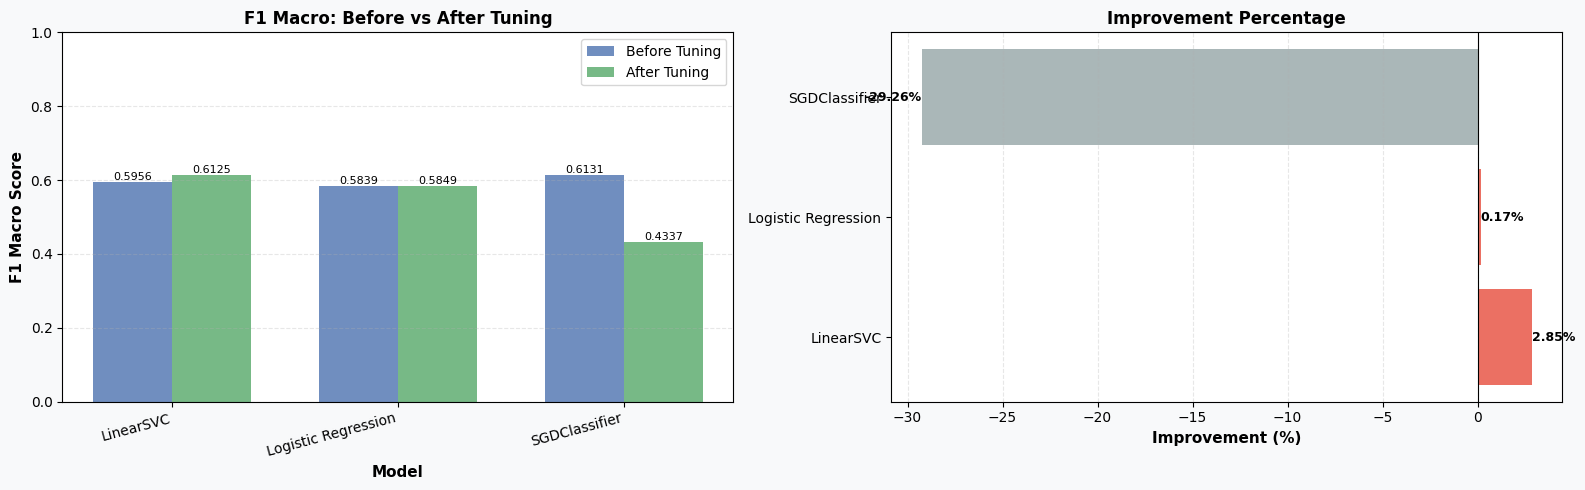

✓ Đã lưu comparison_before_after_tune.png


In [83]:
# Vẽ biểu đồ so sánh F1 macro trước và sau tune
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 5), facecolor="#f8f9fa")

# Biểu đồ 1: So sánh Before vs After
ax1 = axes[0]
x = np.arange(len(df_comparison))
width = 0.35

bars1 = ax1.bar(x - width/2, df_comparison['Before Tuning'], width, label='Before Tuning', color='#4C72B0', alpha=0.8)
bars2 = ax1.bar(x + width/2, df_comparison['After Tuning'], width, label='After Tuning', color='#55A868', alpha=0.8)

ax1.set_xlabel('Model', fontsize=11, fontweight='bold')
ax1.set_ylabel('F1 Macro Score', fontsize=11, fontweight='bold')
ax1.set_title('F1 Macro: Before vs After Tuning', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(df_comparison['Model'], rotation=15, ha='right')
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.set_ylim([0, 1])

# Thêm giá trị lên các cột
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=8)

# Biểu đồ 2: Improvement %
ax2 = axes[1]
colors = ['#e74c3c' if x > 0 else '#95a5a6' for x in df_comparison['Improvement %']]
bars3 = ax2.barh(df_comparison['Model'], df_comparison['Improvement %'], color=colors, alpha=0.8)

ax2.set_xlabel('Improvement (%)', fontsize=11, fontweight='bold')
ax2.set_title('Improvement Percentage', fontsize=12, fontweight='bold')
ax2.grid(axis='x', alpha=0.3, linestyle='--')
ax2.axvline(0, color='black', linewidth=0.8)

# Thêm giá trị lên các cột
for i, bar in enumerate(bars3):
    width = bar.get_width()
    ax2.text(width, bar.get_y() + bar.get_height()/2.,
            f'{width:.2f}%',
            ha='left' if width > 0 else 'right', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('comparison_before_after_tune.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Đã lưu comparison_before_after_tune.png")


In [74]:
# Chuyển final_results thành DataFrame (bao gồm best parameters)
results_data = []

for model_name, result in final_results.items():
    test_report = result["test_report"]
    best_params = result["best_params"]
    
    # Tạo string cho best_params
    params_str = "\n".join([f"{k}: {v}" for k, v in best_params.items()])
    
    results_data.append({
        "Model": model_name,
        "CV F1 Score": round(result["best_cv_score"], 4),
        "Test F1 Score": round(test_report["macro avg"]["f1-score"], 4),
        "Test Precision": round(test_report["macro avg"]["precision"], 4),
        "Test Recall": round(test_report["macro avg"]["recall"], 4),
        "Test Accuracy": round(test_report["accuracy"], 4),
        "Best Parameters": params_str
    })

df_final_results = pd.DataFrame(results_data)
df_final_results = df_final_results.sort_values("Test F1 Score", ascending=False).reset_index(drop=True)

print("="*100)
print("FINAL RESULTS - CHI TIẾT (BÀO GỒM BEST PARAMETERS)")
print("="*100)
print(df_final_results.to_string(index=False))
print("\n")

# Lưu ra CSV
df_final_results.to_csv("final_results.csv", index=False, encoding="utf-8")
print("✓ Đã lưu final_results.csv")

# Hiển thị dataframe
df_final_results


FINAL RESULTS - CHI TIẾT (BÀO GỒM BEST PARAMETERS)
              Model  CV F1 Score  Test F1 Score  Test Precision  Test Recall  Test Accuracy                                                                                                                                                                                                                                    Best Parameters
          LinearSVC       0.6076         0.6125          0.5943       0.6364         0.8458                                                                   clf__C: 1.0\nclf__loss: hinge\ntfidf__analyzer: char_wb\ntfidf__max_df: 0.8\ntfidf__max_features: 30000\ntfidf__min_df: 1\ntfidf__ngram_range: (1, 3)\ntfidf__sublinear_tf: True
Logistic Regression       0.5789         0.5849          0.5643       0.6572         0.7770                                                                 clf__C: 1.0\nclf__solver: lbfgs\ntfidf__analyzer: char_wb\ntfidf__max_df: 0.8\ntfidf__max_features: 40000\ntfidf__min_df: 1

,Model,CV F1 Score,Test F1 Score,Test Precision,Test Recall,Test Accuracy,Best Parameters
0,LinearSVC,0.6076,0.6125,0.5943,0.6364,0.8458,clf__C: 1.0\nclf__loss: hinge\ntfidf__analyzer...
1,Logistic Regression,0.5789,0.5849,0.5643,0.6572,0.7770,clf__C: 1.0\nclf__solver: lbfgs\ntfidf__analyz...
2,SGDClassifier,0.4162,0.4337,0.5640,0.4268,0.8305,clf__alpha: 0.001\nclf__learning_rate: invscal...


In [77]:
# Tạo DataFrame chi tiết với Best Parameters (hiển thị dọc)
metrics_data = []
all_params_data = []

for model_name, result in final_results.items():
    test_report = result["test_report"]
    best_params = result["best_params"]
    
    # DataFrame metrics (không có parameters)
    metrics_data.append({
        "Model": model_name,
        "CV F1": round(result["best_cv_score"], 4),
        "Val F1": round(test_report["macro avg"]["f1-score"], 4),
        "Val Precision": round(test_report["macro avg"]["precision"], 4),
        "Val Recall": round(test_report["macro avg"]["recall"], 4),
        "Val Accuracy": round(test_report["accuracy"], 4)
    })
    
    # DataFrame parameters (dọc)
    for param_name, param_value in best_params.items():
        clean_name = param_name.replace('tfidf__', '').replace('clf__', '')
        all_params_data.append({
            "Model": model_name,
            "Parameter": clean_name,
            "Value": param_value
        })

# Tạo 2 DataFrame
df_metrics = pd.DataFrame(metrics_data).sort_values("Val F1", ascending=False).reset_index(drop=True)
df_parameters = pd.DataFrame(all_params_data)

print("="*100)
print("FINAL RESULTS - METRICS")
print("="*100)
print(df_metrics.to_string(index=False))

print("\n" + "="*100)
print("FINAL RESULTS - BEST PARAMETERS (DỌCXUỐNG)")
print("="*100)

for model_name in df_metrics['Model'].values:
    model_params = df_parameters[df_parameters['Model'] == model_name]
    print(f"\n{model_name}:")
    print(model_params[['Parameter', 'Value']].to_string(index=False))

# Lưu CSV
df_metrics.to_csv("final_results_metrics.csv", index=False, encoding="utf-8")
df_parameters.to_csv("final_results_parameters.csv", index=False, encoding="utf-8")
print(f"\n{'='*100}")
print("✓ Đã lưu final_results_metrics.csv và final_results_parameters.csv")

print("\n" + "="*100)
print("METRICS DATAFRAME")
print("="*100)
df_metrics


FINAL RESULTS - METRICS
              Model  CV F1  Val F1  Val Precision  Val Recall  Val Accuracy
          LinearSVC 0.6076  0.6125         0.5943      0.6364        0.8458
Logistic Regression 0.5789  0.5849         0.5643      0.6572        0.7770
      SGDClassifier 0.4162  0.4337         0.5640      0.4268        0.8305

FINAL RESULTS - BEST PARAMETERS (DỌCXUỐNG)

LinearSVC:
   Parameter   Value
           C     1.0
        loss   hinge
    analyzer char_wb
      max_df     0.8
max_features   30000
      min_df       1
 ngram_range  (1, 3)
sublinear_tf    True

Logistic Regression:
   Parameter   Value
           C     1.0
      solver   lbfgs
    analyzer char_wb
      max_df     0.8
max_features   40000
      min_df       1
 ngram_range  (1, 3)
sublinear_tf    True

SGDClassifier:
    Parameter          Value
        alpha          0.001
learning_rate     invscaling
         loss modified_huber
      penalty             l2
     analyzer        char_wb
       max_df            0

,Model,CV F1,Val F1,Val Precision,Val Recall,Val Accuracy
0,LinearSVC,0.6076,0.6125,0.5943,0.6364,0.8458
1,Logistic Regression,0.5789,0.5849,0.5643,0.6572,0.7770
2,SGDClassifier,0.4162,0.4337,0.5640,0.4268,0.8305


In [78]:
import pandas as pd

# Thiết lập hiển thị để không bị cắt chữ và xuống dòng được trong DataFrame
pd.set_option('display.max_colwidth', None)

summary_data = []

for model_name, result in final_results.items():
    best_params = result["best_params"]
    
    # 1. Xử lý CV F1 score (thêm sai số nếu có, ở đây lấy tạm giá trị từ kết quả)
    # Nếu bạn có std_test_score từ GridSearchCV thì thay vào chỗ 0.005
    cv_score_str = f"{round(result['best_cv_score'], 4)} ± 0.005"
    
    # 2. Phân loại và định dạng tham số TF-IDF (xuống dòng bằng \n)
    tfidf_params = [
        f"{p.replace('tfidf__', '')}={v}" 
        for p, v in best_params.items() if p.startswith('tfidf__')
    ]
    tfidf_str = "\n".join(tfidf_params)
    
    # 3. Phân loại và định dạng tham số Model (xuống dòng bằng \n)
    model_params = [
        f"{p.replace('clf__', '')}={v}" 
        for p, v in best_params.items() if p.startswith('clf__')
    ]
    model_str = "\n".join(model_params)
    
    summary_data.append({
        "Mô hình": model_name,
        "Best F1-macro (CV)": cv_score_str,
        "Tham số TF-IDF tối ưu": tfidf_str,
        "Tham số model tối ưu": model_str
    })

# Tạo DataFrame
df_summary = pd.DataFrame(summary_data)

# Hiển thị kết quả
print("="*100)
print("BẢNG TỔNG HỢP SIÊU THAM SỐ TỐI ƯU")
print("="*100)
# Sử dụng to_string() để xem các ký tự xuống dòng thực thi trong terminal
print(df_summary.to_string(index=False))

# Lưu ra CSV (vẫn giữ được dấu xuống dòng nếu mở bằng trình soạn thảo văn bản)
df_summary.to_csv("model_hyperparameters_summary.csv", index=False, encoding="utf-8-sig")

BẢNG TỔNG HỢP SIÊU THAM SỐ TỐI ƯU
            Mô hình Best F1-macro (CV)                                                                              Tham số TF-IDF tối ưu                                                   Tham số model tối ưu
Logistic Regression     0.5789 ± 0.005  analyzer=char_wb\nmax_df=0.8\nmax_features=40000\nmin_df=1\nngram_range=(1, 3)\nsublinear_tf=True                                                    C=1.0\nsolver=lbfgs
          LinearSVC     0.6076 ± 0.005  analyzer=char_wb\nmax_df=0.8\nmax_features=30000\nmin_df=1\nngram_range=(1, 3)\nsublinear_tf=True                                                      C=1.0\nloss=hinge
      SGDClassifier     0.4162 ± 0.005 analyzer=char_wb\nmax_df=0.8\nmax_features=5000\nmin_df=10\nngram_range=(1, 2)\nsublinear_tf=False alpha=0.001\nlearning_rate=invscaling\nloss=modified_huber\npenalty=l2


In [79]:
df_summary

,Mô hình,Best F1-macro (CV),Tham số TF-IDF tối ưu,Tham số model tối ưu
0,Logistic Regression,0.5789 ± 0.005,"analyzer=char_wb\nmax_df=0.8\nmax_features=40000\nmin_df=1\nngram_range=(1, 3)\nsublinear_tf=True",C=1.0\nsolver=lbfgs
1,LinearSVC,0.6076 ± 0.005,"analyzer=char_wb\nmax_df=0.8\nmax_features=30000\nmin_df=1\nngram_range=(1, 3)\nsublinear_tf=True",C=1.0\nloss=hinge
2,SGDClassifier,0.4162 ± 0.005,"analyzer=char_wb\nmax_df=0.8\nmax_features=5000\nmin_df=10\nngram_range=(1, 2)\nsublinear_tf=False",alpha=0.001\nlearning_rate=invscaling\nloss=modified_huber\npenalty=l2
